# SaaS Customer Churn Prediction

## Objective
The goal of this project is to predict customer churn and identify the key factors driving customer attrition.

This will help businesses proactively retain customers and reduce revenue loss.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Exploratory Data Analysis Questions

The following questions guide the exploratory analysis:

1. What is the distribution of churn in the dataset?
2. Which customer behaviors are associated with higher churn?
3. Do customer service interactions influence churn?
4. Does product usage differ between churned and retained customers?
5. Which features appear most correlated with churn?

In [6]:
df = pd.read_csv("C:\\Users\\erons\\saas-churn-prediction\\data\\raw\\churn-bigml-80.csv")

In [7]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [8]:
df.shape

(2666, 20)

The dataset contains approximately 2,600 customer records with 20 features describing customer behavior and account characteristics.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [11]:
df["Churn"].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [12]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
False    85.45
True     14.55
Name: proportion, dtype: float64

## Churn Distribution-
Retained: 85.45%- Churned: 14.55% 
Class imbalance noted—will address in modeling.

The dataset does not contain missing values. Most variables are numeric usage metrics, while variables such as State and International Plan are categorical.

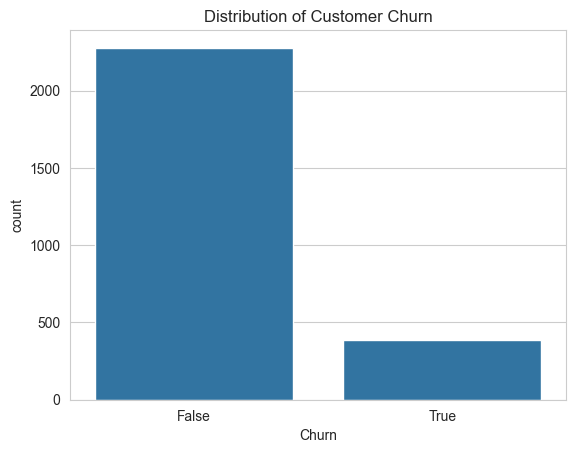

In [13]:
sns.countplot(x="Churn", data=df)

plt.title("Distribution of Customer Churn")
plt.show()

The dataset shows a class imbalance where the majority of customers do not churn. This imbalance must be considered when training machine learning models.

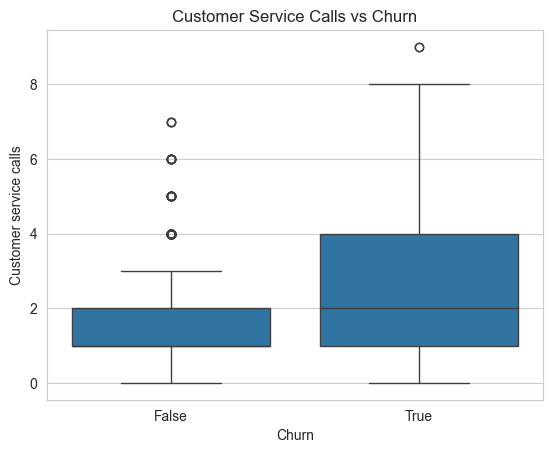

In [14]:
sns.boxplot(
    x="Churn",
    y="Customer service calls",
    data=df
)

plt.title("Customer Service Calls vs Churn")
plt.show()

Customers who churn tend to make more customer service calls, suggesting dissatisfaction may contribute to churn.

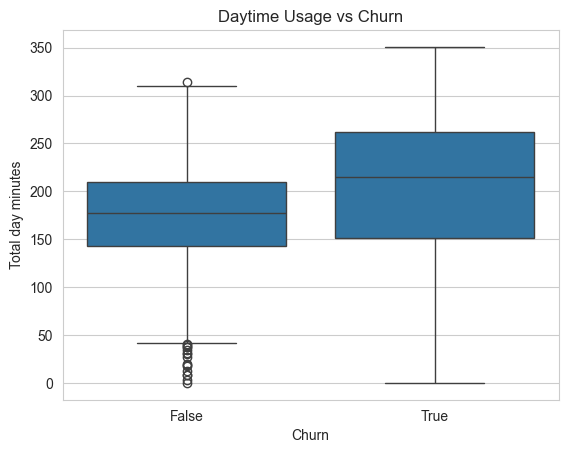

In [15]:
sns.boxplot(
    x="Churn",
    y="Total day minutes",
    data=df
)

plt.title("Daytime Usage vs Churn")
plt.show()

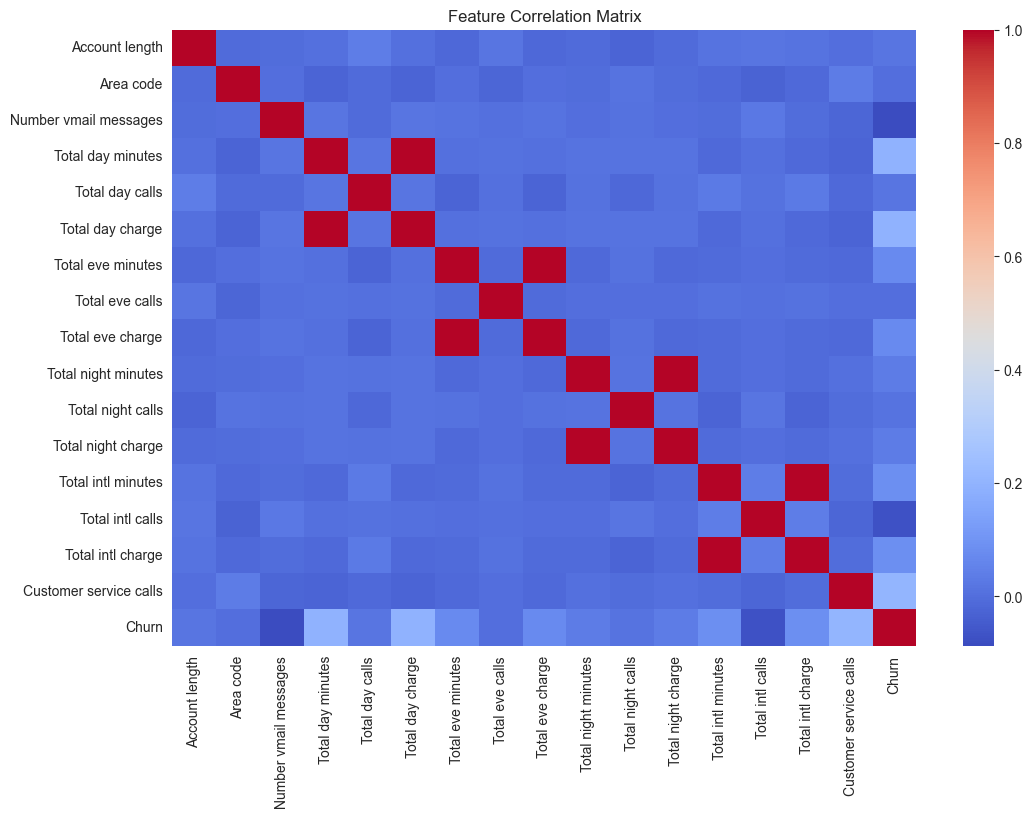

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=["number", "bool"]).corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

### Correlation Analysis Insights

Several feature pairs show extremely high correlation, particularly between usage minutes and their corresponding charges (e.g., total day minutes and total day charge). This is expected because charges are calculated directly from usage.

To reduce redundancy and multicollinearity, one of each pair may be removed during feature selection.

Customer service calls appear to show a stronger relationship with churn compared to most other features, suggesting that dissatisfied customers may be more likely to leave the service.

Most other features exhibit low correlations with each other, indicating that the dataset does not suffer heavily from multicollinearity beyond the usage-charge relationships.

In [ ]:
corr_df = corr_df.sort_values("correlation_with_churn", ascending=False).reset_index(drop=True)
corr_df


,feature,correlation_with_churn,method
0,International plan,0.276864,Cramér's V
1,Customer service calls,0.202590,Pearson (point-biserial for binary target)
2,Total day charge,0.195689,Pearson (point-biserial for binary target)
3,Total day minutes,0.195688,Pearson (point-biserial for binary target)
4,State,0.105709,Cramér's V
5,Voice mail plan,0.097401,Cramér's V
6,Total intl charge,0.086216,Pearson (point-biserial for binary target)
7,Total intl minutes,0.086204,Pearson (point-biserial for binary target)
8,Total eve minutes,0.072906,Pearson (point-biserial for binary target)
9,Total eve charge,0.072893,Pearson (point-biserial for binary target)


Remove the charge columns that are redundant and least correlated with the target variable "churn"

## Churn Driver Analysis

In [ ]:
# Function to calculate correlations with the target variable, handling both numeric and categorical features
def churn_correlations(data, target="Churn"):
    def cramers_v(x, y):
        ct = pd.crosstab(x.fillna("Missing"), y)
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            return np.nan

        obs = ct.values.astype(float)
        n = obs.sum()
        row_sum = obs.sum(axis=1, keepdims=True)
        col_sum = obs.sum(axis=0, keepdims=True)
        expected = (row_sum @ col_sum) / n

        chi2 = np.where(expected > 0, (obs - expected) ** 2 / expected, 0).sum()
        r, k = obs.shape
        phi2 = chi2 / n

        # Bias-corrected Cramér's V
        phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        r_corr = r - ((r - 1) ** 2) / (n - 1)
        k_corr = k - ((k - 1) ** 2) / (n - 1)
        denom = min(k_corr - 1, r_corr - 1)

        return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan

    y = data[target].astype(int)
    results = []

    for col in data.columns:
        if col == target:
            continue

        s = data[col]

        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            x = pd.to_numeric(s, errors="coerce")
            valid = x.notna() & y.notna()
            corr = x[valid].corr(y[valid], method="pearson")
            method = "Pearson (point-biserial for binary target)"
        else:
            corr = cramers_v(s, data[target])
            method = "Cramér's V"

        results.append(
            {
                "feature": col,
                "correlation_with_churn": corr,
                "method": method,
                "abs_correlation": abs(corr) if pd.notna(corr) else np.nan,
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values("abs_correlation", ascending=False)
        .drop(columns="abs_correlation")
        .reset_index(drop=True)
    )

# Example usage:
corr_df = churn_correlations(df, target="Churn")
corr_df

In [31]:
churn_corr = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)
churn_corr

Churn                     1.000000
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Name: Churn, dtype: float64

The variables most correlated with churn include:

- Customer service calls
- Total day minutes
- Total day charge
- Total intl charge

Customer service calls appears to be the strongest indicator of churn, suggesting that customers who frequently contact support may be experiencing dissatisfaction with the service.

## Key Insights
- Churn is moderately imbalanced in the dataset.
- Customers with more customer service calls show higher churn rates.
- Certain usage patterns differ between churned and retained customers.
- Some features(like the charge columns) exhibit strong correlations and may require feature selection or transformation.